# Fusion Model Training

Trains a fusion model (Logistic Regression + Meta-Classifier) on top of 3 submodels:
1. **CNN Transfer** (EfficientNet-B0)
2. **GradField CNN** (CompactGradientNet)
3. **Transformer** (Selectable: ViT-Base or DeiT-Distilled)

In [77]:
# ============================================================
# USER CONFIGURATION — edit this cell only
# ============================================================

# Choose which transformer submodel to include in the fusion.
# Options: "vit-base" | "deit-distilled"
TRANSFORMER_MODEL = "vit-base"

# Paths to model folders (relative to repo root)
MODEL_ROOT = "../models"
HF_CACHE_ROOT = "../models/.hf_cache"

# Active submodels — CNN and Gradfield are always included.
# The transformer slot is filled by TRANSFORMER_MODEL above.
ACTIVE_SUBMODELS = ["cnn-transfer", TRANSFORMER_MODEL, "gradfield-cnn"]

# Fusion settings
FUSION_THRESHOLD = 0.5
TEST_SPLIT = 0.2
RANDOM_SEED = 42

# HuggingFace org to upload to
HF_ORG = "DeepFakeDetector"
# ============================================================

In [78]:
# Setup & Imports
import os
import sys
import time
import math
import json
import glob
import random
import joblib
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Callable
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import huggingface_hub

# Set seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"Active submodels: {ACTIVE_SUBMODELS}")
print(f"Transformer slot: {TRANSFORMER_MODEL}")

Using device: cpu
Active submodels: ['cnn-transfer', 'vit-base', 'gradfield-cnn']
Transformer slot: vit-base


In [79]:
# ============================================================
# CompactGradientNet Definition (Self-Contained)
# ============================================================
class CompactGradientNet(nn.Module):
    def __init__(self, depth=4, base_filters=32, dropout=0.3, embedding_dim=128):
        """
        CNN for gradient field classification with discriminative features.
        5-channel input: [Gx, Gy, magnitude, angle, coherence]
        """
        super().__init__()

        # Sobel kernels
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                               dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                               dtype=torch.float32).view(1, 1, 3, 3)
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)

        # Gaussian kernel for structure tensor smoothing
        gaussian = torch.tensor([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4],
                                  [6, 24, 36, 24, 6], [4, 16, 24, 16, 4],
                                  [1, 4, 6, 4, 1]], dtype=torch.float32) / 256.0
        self.register_buffer('gaussian', gaussian.view(1, 1, 5, 5))

        # CNN layers
        layers = []
        in_ch = 5
        for i in range(depth):
            out_ch = base_filters * (2**i)
            layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                nn.MaxPool2d(2)
            ])
            if dropout > 0:
                layers.append(nn.Dropout2d(dropout))
            in_ch = out_ch

        self.cnn = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.embedding = nn.Linear(out_ch, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, 1)

    def compute_gradient_field(self, luminance):
        """Compute 5-channel gradient field on GPU."""
        G_x = F.conv2d(luminance, self.sobel_x, padding=1)
        G_y = F.conv2d(luminance, self.sobel_y, padding=1)

        magnitude = torch.sqrt(G_x**2 + G_y**2 + 1e-8)
        angle = torch.atan2(G_y, G_x) / math.pi

        # Structure tensor for coherence
        Gxx, Gxy, Gyy = G_x * G_x, G_x * G_y, G_y * G_y
        Sxx = F.conv2d(Gxx, self.gaussian, padding=2)
        Sxy = F.conv2d(Gxy, self.gaussian, padding=2)
        Syy = F.conv2d(Gyy, self.gaussian, padding=2)

        trace = Sxx + Syy
        det_term = torch.sqrt((Sxx - Syy)**2 + 4 * Sxy**2 + 1e-8)
        lambda1, lambda2 = 0.5 * (trace + det_term), 0.5 * (trace - det_term)
        coherence = ((lambda1 - lambda2) / (lambda1 + lambda2 + 1e-8))**2

        magnitude_scaled = torch.log1p(magnitude * 10)

        return torch.cat([G_x, G_y, magnitude_scaled, angle, coherence], dim=1)

    def forward(self, luminance):
        # luminance shape: (B, 1, H, W)
        x = self.compute_gradient_field(luminance)
        x = self.cnn(x)
        x = self.global_pool(x).flatten(1)
        emb = self.embedding(x)
        logit = self.classifier(emb)
        return logit.squeeze(1)


In [80]:
# ============================================================
# Data Loading & Preprocessing
# ============================================================

class LuminanceDataset(Dataset):
    """
    Dataset for GradField CNN: Loads image, converts to Grayscale (Luminance),
    and returns (1, 256, 256) tensor.
    """
    def __init__(self, img_paths: list[str], labels: list[int], img_size=256):
        self.img_paths = img_paths
        self.labels = labels
        self.img_size = img_size
        self.resize = transforms.Resize((img_size, img_size))
        # BT.709 luminance coefficients
        self.R_COEFF = 0.2126
        self.G_COEFF = 0.7152
        self.B_COEFF = 0.0722

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        img = self.resize(img)
        img_tensor = transforms.functional.to_tensor(img)
        # RGB -> Luminance (BT.709)
        luminance = (self.R_COEFF * img_tensor[0] +
                     self.G_COEFF * img_tensor[1] +
                     self.B_COEFF * img_tensor[2])
        luminance = luminance.unsqueeze(0)  # (1, H, W)
        return luminance.float(), torch.tensor(self.labels[idx], dtype=torch.float32)

class StandardDataset(Dataset):
    """
    Dataset for CNN/ViT/DeiT: Loads image, standard ImageNet preprocessing.
    """
    def __init__(self, img_paths: list[str], labels: list[int], img_size=224):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

def get_image_paths_and_labels(base_dir, max_samples=None):
    """Crawls recursively for real/fake images."""
    paths, labels = [], []
    # Standard structure: base_dir/real, base_dir/fake
    # OR base_dir/train/real etc.
    # We search specifically for 'real' and 'fake' folders
    
    for label_name, label_val in [("real", 0), ("fake", 1)]:
        # Look for subdirectories named exactly 'real' or 'fake'
        found_dirs = glob.glob(f"{base_dir}/**/{label_name}", recursive=True)
        for d in found_dirs:
            files = glob.glob(f"{d}/*.jpg") + glob.glob(f"{d}/*.png") + glob.glob(f"{d}/*.jpeg")
            if max_samples:
                files = files[:max_samples]
            paths.extend(files)
            labels.extend([label_val] * len(files))
            
    return paths, labels

In [81]:
# ============================================================
# Model Loaders
# ============================================================

def load_cnn_transfer(path_or_cache):
    """Loads EfficientNet-B0 (Binary Class)"""
    print(f"Loading cnn-transfer from {path_or_cache}...")
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    
    # Try loading from .pth or safe_tensor
    # Heuristic: look for model.pth inside
    weight_path = os.path.join(path_or_cache, "model.pth")
    if not os.path.exists(weight_path):
        # Check if we are pointing to the file directly
        if path_or_cache.endswith(".pth"):
             weight_path = path_or_cache
        else:
             raise FileNotFoundError(f"Could not find model.pth in {path_or_cache}")
             
    state_dict = torch.load(weight_path, map_location=device)
    # Handle state dict keys if needed
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

def load_vit_base(path_or_cache):
    """Loads ViT-B/16 (Binary Class)"""
    print(f"Loading vit-base from {path_or_cache}...")
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
    
    # Reconstruct custom MLP head to match checkpoint (fc1, fc2)
    # (768 -> 512 -> 2)
    model.head = nn.Sequential(
        nn.Linear(768, 512),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(512, 2)
    )
    
    weight_path = os.path.join(path_or_cache, "deepfake_vit_finetuned_wildfake.pth")
    if not os.path.exists(weight_path):
         files = glob.glob(f"{path_or_cache}/*.pth")
         if files: weight_path = files[0]

    state_dict = torch.load(weight_path, map_location=device)
    if "model" in state_dict:
        state_dict = state_dict["model"]
        
    new_state_dict = {}

    for k, v in state_dict.items():
        # 1. Handle custom head keys (fc1/fc2 are at the top level, no 'vit.' prefix)
        if k.startswith("fc1."):
             k = k.replace("fc1.", "head.0.")
        elif k.startswith("fc2."):
             k = k.replace("fc2.", "head.3.")
             
        # 2. Handle standard vit keys (strip 'vit.' prefix)
        elif k.startswith("vit."):
            k = k.replace("vit.", "", 1)
        
        new_state_dict[k] = v    
    
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()
    return model

def load_deit_distilled(path_or_cache):
    """Loads DeiT-Distilled with Custom Head (Binary Class)"""
    print(f"Loading deit-distilled from {path_or_cache}...")
    model = timm.create_model('deit_base_distilled_patch16_224', pretrained=False)
    
    # Reconstruct custom head: (768 -> 512 -> 2)
    # Note: DeiT has 'head' and 'head_dist'. We replace 'head' with our MLP.
    # As per training script, head_dist shares weights with head.
    model.head = nn.Sequential(
        nn.LayerNorm(768),
        nn.Linear(768, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, 2)
    )
    if hasattr(model, "head_dist"):
        model.head_dist = model.head  # Share weights as per training setup
    
    weight_path = os.path.join(path_or_cache, "deit_distilled_custom_head.pt")
    if not os.path.exists(weight_path):
         # Fallback
         files = glob.glob(f"{path_or_cache}/*.pt")
         if files: weight_path = files[0]

    state_dict = torch.load(weight_path, map_location=device)
    model.load_state_dict(state_dict, strict=False) 
    model.to(device)
    model.eval()
    return model

def load_gradfield_cnn(path_or_cache):
    """Loads CompactGradientNet"""
    print(f"Loading gradfield-cnn from {path_or_cache}...")
    model = CompactGradientNet()
    
    weight_path = os.path.join(path_or_cache, "gradient_field_cnn_v2.pth")
    if not os.path.exists(weight_path):
         files = glob.glob(f"{path_or_cache}/*.pth")
         if files: weight_path = files[0]
            
    state_dict = torch.load(weight_path, map_location=device, weights_only=False)
    if "model" in state_dict:
        state_dict = state_dict["model"]

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

# Registry
ALL_LOADERS = {
    "cnn-transfer": load_cnn_transfer,
    "vit-base": load_vit_base,
    "deit-distilled": load_deit_distilled,
    "gradfield-cnn": load_gradfield_cnn,
}

# Instantiate Active Submodels
loaded_models = {}
for name in ACTIVE_SUBMODELS:
    # Determine path: Check MODEL_ROOT first, then HF_CACHE_ROOT
    path = os.path.join(MODEL_ROOT, name)
    if not os.path.exists(path):
        # Try HF Cache pattern
        path = os.path.join(HF_CACHE_ROOT, f"DeepFakeDetector--{name}")
    
    if not os.path.exists(path) and name == "gradfield-cnn":
         # Fallback for gradfield specific path layout if needed
         path = os.path.join(MODEL_ROOT, "grad_field_cnn")

    if os.path.exists(path):
        loaded_models[name] = ALL_LOADERS[name](path)
    else:
        print(f"WARNING: Could not find weights for {name} at {path}. Skipping.")


Loading cnn-transfer from ../models/.hf_cache/DeepFakeDetector--cnn-transfer...
Loading vit-base from ../models/.hf_cache/DeepFakeDetector--vit-base...
Loading gradfield-cnn from ../models/.hf_cache/DeepFakeDetector--gradfield-cnn...


In [82]:
# ============================================================
# 1. Collect Probabilities (Inference)
# ============================================================

# Load Validation Data (using a subset of training data or explicit validation set)
# For this notebook, we'll crawl the 'datasets' folder
all_paths, all_labels = get_image_paths_and_labels("../datasets", max_samples=500)
print(f"Found {len(all_paths)} images.")

if len(all_paths) == 0:
    raise ValueError("No images found in datasets folder. Please ensure datasets are mounted/available.")

# Split into Train/Val for Fusion Training (80/20)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=all_labels
)

# Datasets
# We need two datasets per split because GradField needs different preprocessing
ds_std_train = StandardDataset(train_paths, train_labels)
ds_lum_train = LuminanceDataset(train_paths, train_labels)

ds_std_val = StandardDataset(val_paths, val_labels)
ds_lum_val = LuminanceDataset(val_paths, val_labels)

def get_probas(models_dict, ds_std, ds_lum):
    """
    Run inference on all models and stack probabilities.
    Returns: X (N, num_models), y (N,)
    """
    probs_list = []
    labels_list = []
    
    # We iterate by index to ensure alignment
    # Assuming ds_std and ds_lum default to same order/paths
    
    dl_std = DataLoader(ds_std, batch_size=32, shuffle=False, num_workers=0)
    dl_lum = DataLoader(ds_lum, batch_size=32, shuffle=False, num_workers=0)
    
    # We need to iterate both dataloaders simultaneously
    # But DataLoader doesn't guarantee strict alignment if shuffled (it is False here)
    
    with torch.no_grad():
        for (img_std, y), (img_lum, _) in tqdm(zip(dl_std, dl_lum), total=len(dl_std)):
            img_std = img_std.to(device)
            img_lum = img_lum.to(device)
            
            batch_probs = []
            
            for name in ACTIVE_SUBMODELS:
                model = models_dict[name]
                if name == "gradfield-cnn":
                     logits = model(img_lum)
                     p = torch.sigmoid(logits)
                elif name == "cnn-transfer":
                     logits = model(img_std)
                     p = torch.softmax(logits, dim=1)[:, 1]
                else: # vit or deit (2-class output)
                     logits = model(img_std)
                     p = torch.softmax(logits, dim=1)[:, 1] # prob of class 1 (fake)
                
                batch_probs.append(p.cpu().numpy())
            
            # Stack along feature axis: (Batch, Num_Models)
            batch_probs = np.stack(batch_probs, axis=1)
            probs_list.append(batch_probs)
            labels_list.append(y.numpy())
            
    return np.concatenate(probs_list), np.concatenate(labels_list)

print("Generating probabilities for Fusion Training...")
X_train, y_train = get_probas(loaded_models, ds_std_train, ds_lum_train)
X_val, y_val = get_probas(loaded_models, ds_std_val, ds_lum_val)

# Save validation data
val_data = {
    "submodel_order": ACTIVE_SUBMODELS,
    "rows": []
}
for i in range(len(y_val)):
    val_data["rows"].append({
        "probs": X_val[i].tolist(),
        "label": int(y_val[i])
    })
    
with open("validation_data.json", "w") as f:
    json.dump(val_data, f, indent=2)
print("Saved validation_data.json")

Found 400 images.
Generating probabilities for Fusion Training...


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Saved validation_data.json


In [83]:
# ============================================================
# 2. Train Fusion Model (Logistic Regression)
# ============================================================

fusion_logreg = LogisticRegression(random_state=RANDOM_SEED)
fusion_logreg.fit(X_train, y_train)

print("Fusion Model Trained (Logistic Regression)")
print("Coefficients (Contribution):")
for name, coef in zip(ACTIVE_SUBMODELS, fusion_logreg.coef_[0]):
    print(f"  {name}: {coef:.4f}")
print(f"  Intercept: {fusion_logreg.intercept_[0]:.4f}")

Fusion Model Trained (Logistic Regression)
Coefficients (Contribution):
  cnn-transfer: 4.6120
  vit-base: -2.7946
  gradfield-cnn: 1.4649
  Intercept: -0.2501


--- Logistic Regression Fusion Results ---
Accuracy: 0.9375
AUROC:    0.9596
F1 Score: 0.9580


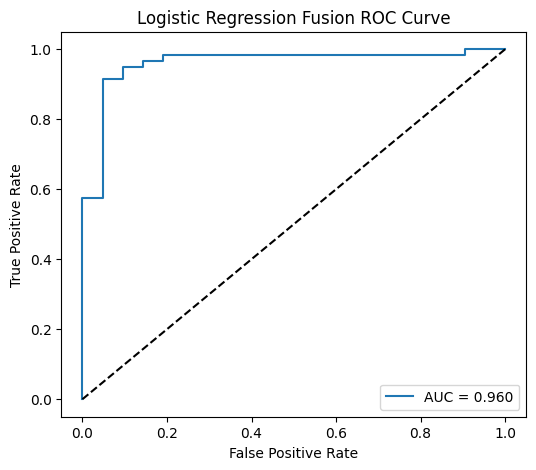

In [84]:
# ============================================================
# 3. Evaluate
# ============================================================

def evaluate_fusion(model, X, y, title="Fusion"):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= FUSION_THRESHOLD).astype(int)
    
    acc = accuracy_score(y, preds)
    auroc = roc_auc_score(y, probs)
    f1 = f1_score(y, preds)
    
    print(f"--- {title} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUROC:    {auroc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot ROC
    fpr, tpr, _ = roc_curve(y, probs)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {auroc:.3f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f'{title} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
    
    return {
        "accuracy": acc,
        "auroc": auroc,
        "f1": f1,
        "model_type": title
    }

metrics_logreg = evaluate_fusion(fusion_logreg, X_val, y_val, title="Logistic Regression Fusion")

# Save Metrics
metrics_logreg["submodel_order"] = ACTIVE_SUBMODELS
with open("test_metrics.json", "w") as f:
    json.dump(metrics_logreg, f, indent=2)

In [85]:
# ============================================================
# 4. Meta-Classifier (Stretch Goal)
# ============================================================

class MetaClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

input_dim = len(ACTIVE_SUBMODELS)
meta_model = MetaClassifier(input_dim).to(device)
optimizer = torch.optim.Adam(meta_model.parameters(), lr=0.01)
criterion = nn.BCELoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

print("Training Meta-Classifier...")
meta_model.train()
for epoch in range(500): # Simple loop
    optimizer.zero_grad()
    preds = meta_model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

print("Meta-Classifier Trained")

# Evaluate Meta-Classifier
meta_model.eval()
with torch.no_grad():
    probs_meta = meta_model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()

preds_meta = (probs_meta >= FUSION_THRESHOLD).astype(int)
acc_meta = accuracy_score(y_val, preds_meta)
auc_meta = roc_auc_score(y_val, probs_meta)
print(f"Meta-Classifier AUROC: {auc_meta:.4f}")

Training Meta-Classifier...
Epoch 0: Loss 0.6258
Epoch 100: Loss 0.2579
Epoch 200: Loss 0.2313
Epoch 300: Loss 0.2130
Epoch 400: Loss 0.2095
Meta-Classifier Trained
Meta-Classifier AUROC: 0.9798


In [ ]:
# ============================================================
# 5. Export and Upload to HuggingFace
# ============================================================

def create_repo_structure(repo_name, model_obj, is_pytorch=False):
    os.makedirs(repo_name, exist_ok=True)
    
    # 1. Save Model
    if is_pytorch:
        torch.save(model_obj.state_dict(), f"{repo_name}/fusion_model.pt")
    else: # sklearn
        joblib.dump(model_obj, f"{repo_name}/fusion_logreg.pkl")
        
    # 2. Config
    config = {
        "type": "probability_stacking_fusion",
        "name": repo_name,
        "version": "1.0.0",
        "submodels": [f"{HF_ORG}/{name}" for name in ACTIVE_SUBMODELS],
        "submodel_order": ACTIVE_SUBMODELS,
        "num_submodels": len(ACTIVE_SUBMODELS),
        "threshold": FUSION_THRESHOLD,
        "labels": {"0": "real", "1": "fake"}
    }
    with open(f"{repo_name}/config.json", "w") as f:
        json.dump(config, f, indent=2)
        
    # 3. Label Map
    with open(f"{repo_name}/label_map.json", "w") as f:
        json.dump({"0": "real", "1": "fake"}, f)
        
    # 4. Metrics
    if os.path.exists("test_metrics.json"):
        import shutil
        shutil.copy("test_metrics.json", f"{repo_name}/test_metrics.json")
        
    # 5. Predict Script
    predict_code = """
import numpy as np
import os
import json

def predict(submodel_outputs: dict, **kwargs) -> dict:
    '''
    Standard Fusion Predict Interface
    Args:
        submodel_outputs: dict mapping model_name -> {"prob_fake": float}
    '''
    # Load config to get order
    base_path = os.path.dirname(__file__)
    with open(os.path.join(base_path, "config.json")) as f:
        config = json.load(f)
        
    order = config["submodel_order"]
    probs = []
    for name in order:
        if name not in submodel_outputs:
            raise ValueError(f"Missing output for {name}")
        probs.append(submodel_outputs[name]["prob_fake"])
    
    X = np.array([probs]) # (1, n_models)
    
    # Load Model
    # Detect if logreg or pytorch
    if os.path.exists(os.path.join(base_path, "fusion_logreg.pkl")):
        import joblib
        model = joblib.load(os.path.join(base_path, "fusion_logreg.pkl"))
        prob_fake = model.predict_proba(X)[0, 1]
    elif os.path.exists(os.path.join(base_path, "fusion_model.pt")):
        import torch
        import torch.nn as nn
        # Simple reconstruction of architecture (must match training)
        # For robustness, one might pickle the whole model or save arch config.
        # Here we assume the simple MLP structure used in notebook.
        input_dim = len(order)
        net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        net.load_state_dict(torch.load(os.path.join(base_path, "fusion_model.pt")))
        net.eval()
        with torch.no_grad():
            prob_fake = net(torch.tensor(X, dtype=torch.float32)).item()
    else:
        raise FileNotFoundError("No model file found")
        
    return {
        "pred": "fake" if prob_fake >= config.get("threshold", 0.5) else "real",
        "pred_int": 1 if prob_fake >= config.get("threshold", 0.5) else 0,
        "prob_fake": float(prob_fake),
        "meta": {"min_prob": float(np.min(probs)), "max_prob": float(np.max(probs))}
    }
    """
    with open(f"{repo_name}/predict.py", "w") as f:
        f.write(predict_code)
        
    print(f"Prepared {repo_name} for upload.")

# Export LogReg
create_repo_structure("fusion-logreg", fusion_logreg, is_pytorch=False)

# Export Meta-Classifier
create_repo_structure("fusion-meta-classifier", meta_model, is_pytorch=True)

print("Upload command (run in terminal):")
print(f"hf upload {HF_ORG}/fusion-logreg ./fusion-logreg . --create-repo")
print(f"hf upload {HF_ORG}/fusion-meta-classifier ./fusion-meta-classifier . --create-repo")

Prepared fusion-logreg for upload.
Prepared fusion-meta-classifier for upload.
Upload command (run in terminal):
huggingface-cli upload DeepFakeDetector/fusion-logreg ./fusion-logreg . --create-repo
huggingface-cli upload DeepFakeDetector/fusion-meta-classifier ./fusion-meta-classifier . --create-repo
